# Figures for the continuous-time paper

Synthesis figures drawn from the existing continuous-time studies — no new training.
Sources: `../Network_size_study/results/runs/` (600 runs: the inner/outer gallery and the
success map), `../Causal_weighting/results/` (the worked example), `../../RK_Truth` (the
reference and the vector field). Each figure states what it is for in its cell.

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path.cwd().parent / "Network_size_study"))
sys.path.insert(0, str(Path.cwd().parent.parent / "RK_Truth"))
import capacity as cap
import vanderpol

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

RUNS = cap.RESULTS
rows = [json.loads(p.read_text()) for p in sorted(RUNS.glob("causal_T14_*.json"))]
rows = [r for r in rows if not r.get("smoke")]
S = cap.starts()
print(f"{len(rows)} causal T=14 runs loaded; starts:")
print(S.round(2))

150 causal T=14 runs loaded; starts:
[[ 2.    0.  ]
 [-0.86 -0.24]
 [-0.03 -1.02]
 [ 0.87  1.76]
 [ 1.85  2.9 ]
 [-2.32 -2.79]]


## Figure A — the pipeline: how one trajectory is made

A schematic of the whole process, for the "making a trajectory" section: the inputs, the
network, where the physics enters, the two training recipes, and the validation step. Boxes
only — every box is explained in full in the text.

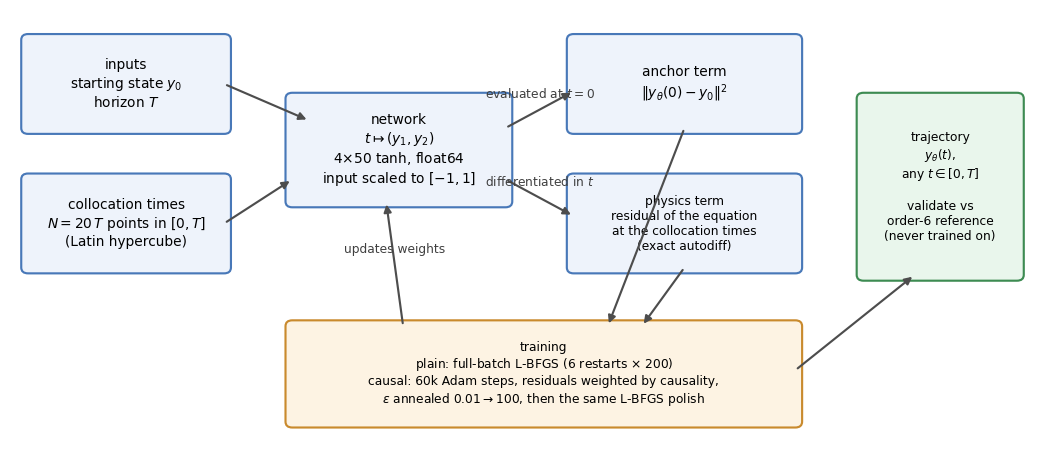

In [2]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 6); ax.axis("off")

def box(x, y, w, h, text, fc="#eef3fb", ec="#4878b8", fs=9):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0.08", fc=fc, ec=ec, lw=1.4))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs)

def arrow(x0, y0, x1, y1, text=None, fs=8):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="0.3", lw=1.4))
    if text:
        ax.text((x0+x1)/2, (y0+y1)/2 + 0.16, text, ha="center",
                fontsize=fs, color="0.25")

box(0.2, 4.4, 2.3, 1.2, "inputs\nstarting state $y_0$\nhorizon $T$")
box(0.2, 2.5, 2.3, 1.2, "collocation times\n$N = 20\,T$ points in $[0,T]$\n(Latin hypercube)")
box(3.3, 3.4, 2.5, 1.4, "network\n$t \\mapsto (y_1, y_2)$\n4$\\times$50 tanh, float64\ninput scaled to $[-1,1]$")
box(6.6, 4.4, 2.6, 1.2, "anchor term\n$\\|y_\\theta(0) - y_0\\|^2$")
box(6.6, 2.5, 2.6, 1.2, "physics term\nresidual of the equation\nat the collocation times\n(exact autodiff)", fs=8)
box(3.3, 0.4, 5.9, 1.3,
    "training\nplain: full-batch L-BFGS (6 restarts $\\times$ 200)\n"
    "causal: 60k Adam steps, residuals weighted by causality,\n"
    "$\\varepsilon$ annealed 0.01$\\to$100, then the same L-BFGS polish", fc="#fdf3e3", ec="#c98a2d", fs=8)
box(10.0, 2.4, 1.8, 2.4, "trajectory\n$y_\\theta(t)$,\nany $t \\in [0,T]$\n\nvalidate vs\norder-6 reference\n(never trained on)", fc="#e9f6ec", ec="#3d8b52", fs=8)

arrow(2.5, 5.0, 3.5, 4.5)
arrow(2.5, 3.1, 3.3, 3.7)
arrow(5.8, 4.4, 6.6, 4.9, "evaluated at $t=0$")
arrow(5.8, 3.7, 6.6, 3.2, "differentiated in $t$")
arrow(7.9, 4.4, 7.0, 1.7)
arrow(7.9, 2.5, 7.4, 1.7)
arrow(4.6, 1.7, 4.4, 3.4, "updates weights")
arrow(9.2, 1.1, 10.6, 2.4)
fig.savefig(FIGURES / "A_pipeline.png", bbox_inches="tight")
plt.show()

## Figure B — the inner/outer gallery

For each of the six starting states of the size sweep: the **best causally weighted
$T = 14$ run** (of the 25 architectures) in the phase plane, against its own reference.
The outer starts are tracked around the loop; the inner starts — the ones beginning near
the repelling equilibrium — are never solved by any architecture.

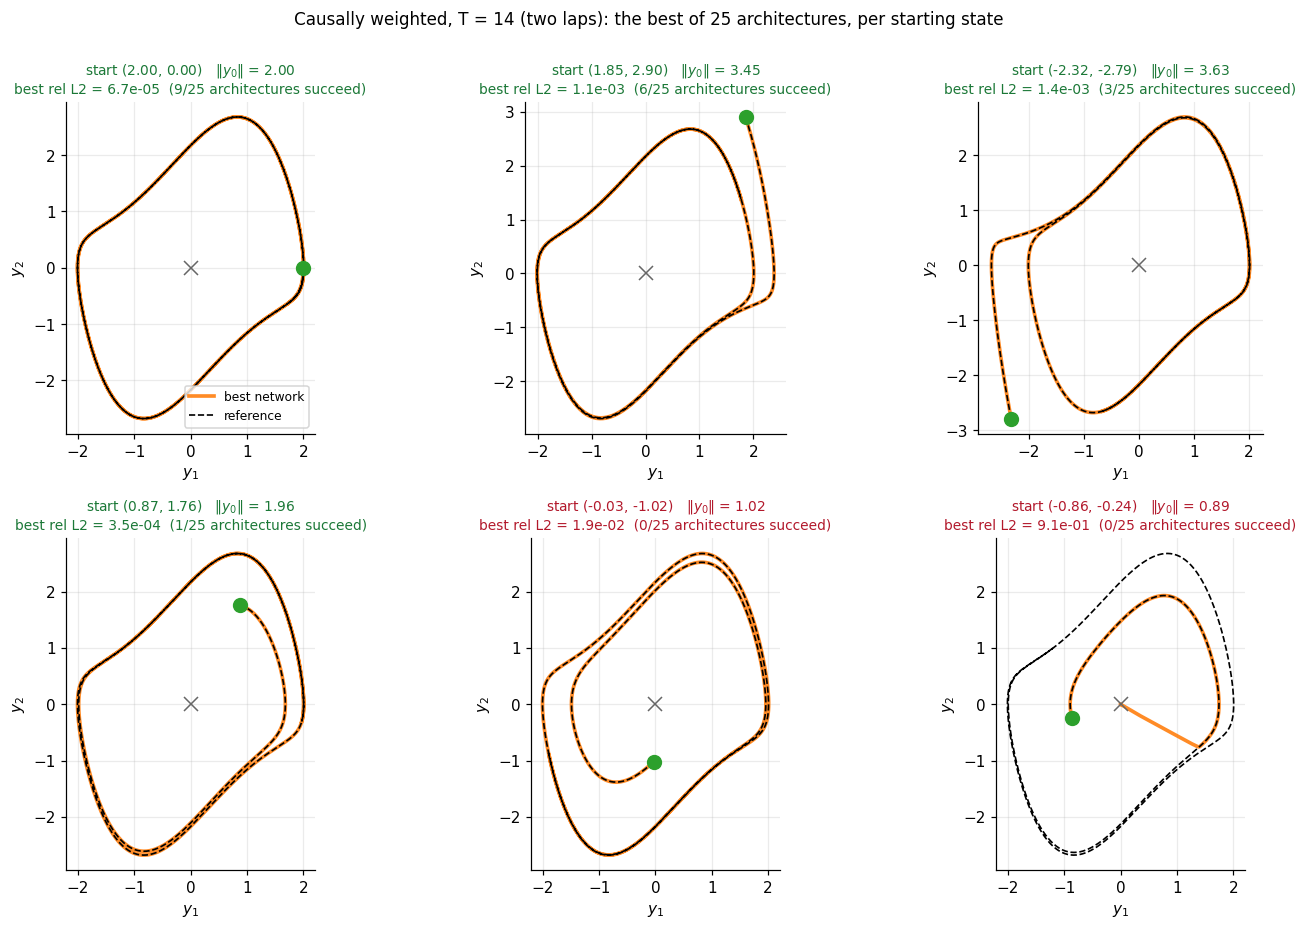

In [3]:
best = {}
for r in rows:
    s = r["start_idx"]
    if s not in best or r["rel_l2"] < best[s]["rel_l2"]:
        best[s] = r

fig, axes = plt.subplots(2, 3, figsize=(13, 8.4))
order = [0, 4, 5, 3, 2, 1]          # outer three on top, harder below
for ax, s in zip(axes.flat, order):
    r = best[s]
    z = np.load(RUNS / (r["tag"] + ".npz"))
    y_net = z["y_net"]
    t_ref, y_ref = cap.reference(S[s], 14.0)
    ax.plot(y_net[:, 0], y_net[:, 1], "-", color="C1", lw=2.4, alpha=0.9,
            label="best network", zorder=4)
    ax.plot(y_ref[:, 0], y_ref[:, 1], "k--", lw=1.1, label="reference", zorder=5)
    ax.plot(*S[s], "o", color="C2", ms=9, zorder=6)
    ax.plot(0, 0, "x", color="0.4", ms=9, zorder=6)
    ok = r["rel_l2"] < 1e-2
    n_succ = sum(1 for q in rows if q["start_idx"] == s and q["rel_l2"] < 1e-2)
    ax.set_title(f"start ({S[s][0]:.2f}, {S[s][1]:.2f})   "
                 f"$\\|y_0\\|$ = {np.linalg.norm(S[s]):.2f}\n"
                 f"best rel L2 = {r['rel_l2']:.1e}  ({n_succ}/25 architectures succeed)",
                 fontsize=9,
                 color="#1b7837" if ok else "#b2182b")
    ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$")
    ax.set_aspect("equal")
axes[0, 0].legend(fontsize=8, loc="lower right")
fig.suptitle("Causally weighted, T = 14 (two laps): the best of 25 architectures, per starting state",
             fontsize=11, y=1.0)
fig.tight_layout()
fig.savefig(FIGURES / "B_start_gallery.png", bbox_inches="tight")
plt.show()

## Figure C — the same disagreement in time

Two starts side by side, position against time: the easiest start (2, 0) tracked for both
laps at $10^{-4}$, and the never-solved start (−0.86, −0.24) collapsing onto the
equilibrium — the clearest single picture of the inner/outer disagreement.

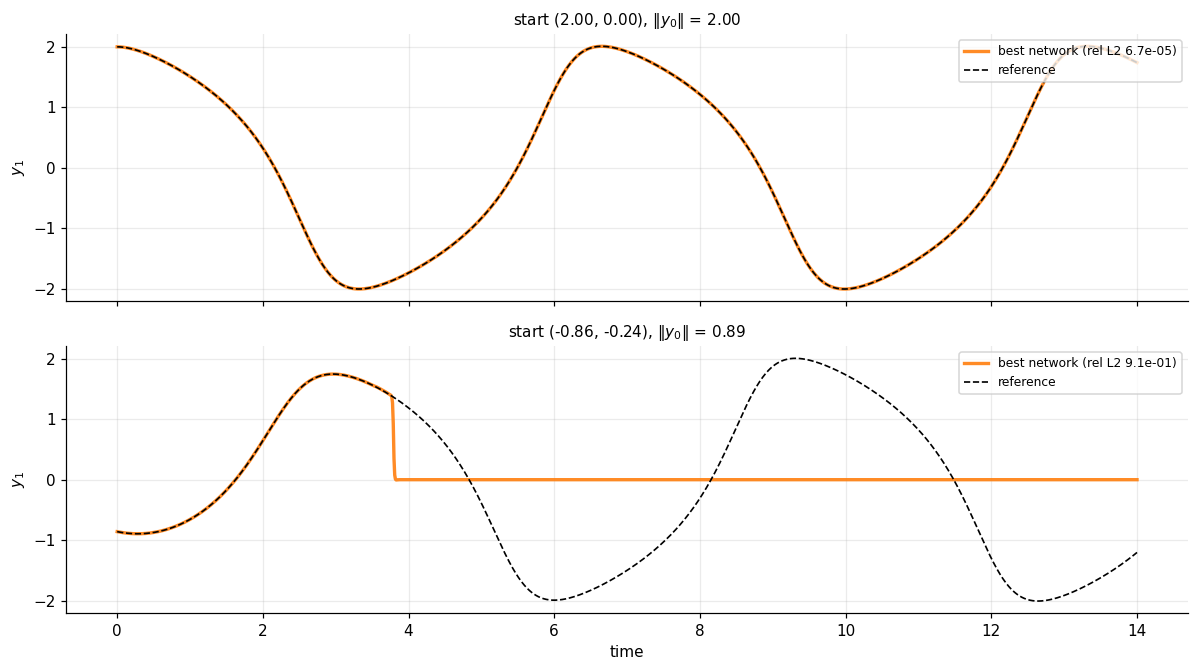

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)
for ax, s in zip(axes, [0, 1]):
    r = best[s]
    z = np.load(RUNS / (r["tag"] + ".npz"))
    t_ref, y_ref = cap.reference(S[s], 14.0)
    ax.plot(t_ref, z["y_net"][:, 0], "-", color="C1", lw=2.2, alpha=0.9,
            label=f"best network (rel L2 {r['rel_l2']:.1e})", zorder=4)
    ax.plot(t_ref, y_ref[:, 0], "k--", lw=1.1, label="reference", zorder=5)
    ax.set_ylabel("$y_1$")
    ax.set_title(f"start ({S[s][0]:.2f}, {S[s][1]:.2f}), $\\|y_0\\|$ = {np.linalg.norm(S[s]):.2f}",
                 fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
axes[1].set_xlabel("time")
fig.tight_layout()
fig.savefig(FIGURES / "C_inner_outer_time.png", bbox_inches="tight")
plt.show()

## Figure D — the success map

The six starting states drawn on the phase plane over the van der Pol vector field and the
limit cycle, coloured by their success rate (causally weighted, $T = 14$, 25 architectures
each). Geometry is the message: success falls off with proximity to the repelling
equilibrium, where the impostor solution lives.

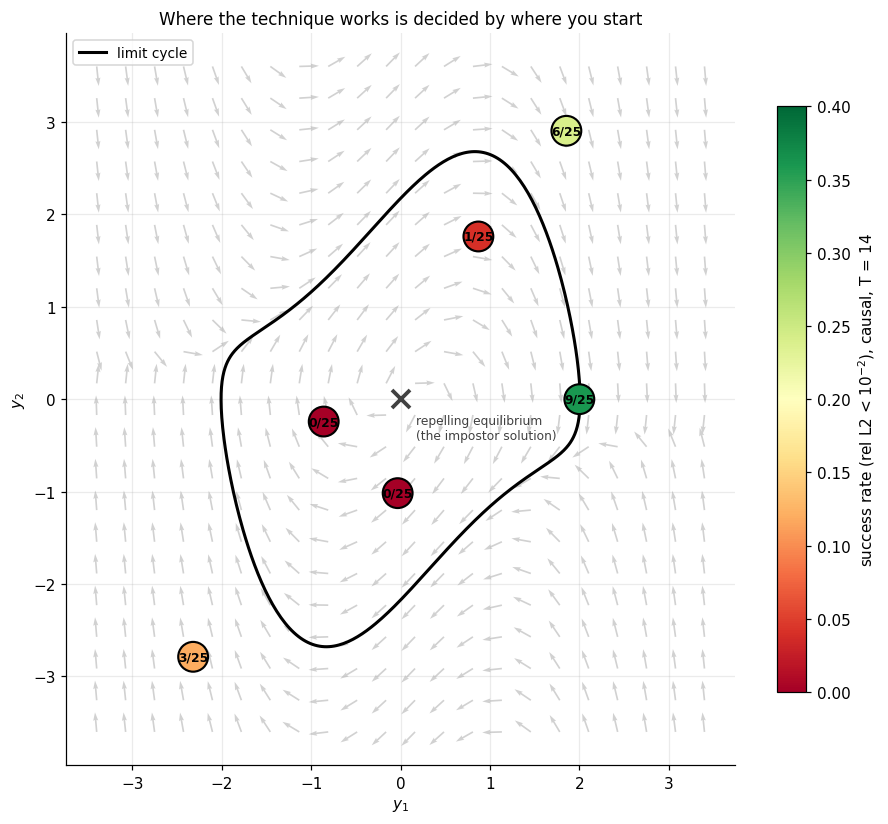

In [5]:
t_ref_full, y_loop = cap.reference(np.array([2.0, 0.0]), 40.0)
lap = 6.663286859
loop = y_loop[t_ref_full >= 40.0 - lap]

Y1, Y2, U, V = vanderpol.vector_field((-3.4, 3.4), (-3.6, 3.6), n=22)

fig, ax = plt.subplots(figsize=(8.4, 7.6))
sp = np.sqrt(U**2 + V**2)
ax.quiver(Y1, Y2, U/sp, V/sp, color="0.82", scale=34, width=0.0025, zorder=1)
ax.plot(loop[:, 0], loop[:, 1], "k-", lw=2.0, label="limit cycle", zorder=3)
ax.plot(0, 0, "x", color="0.25", ms=12, mew=2.5, zorder=4)
ax.annotate("repelling equilibrium\n(the impostor solution)", (0, 0),
            textcoords="offset points", xytext=(10, -26), fontsize=8, color="0.25")

succ = {s: sum(1 for q in rows if q["start_idx"] == s and q["rel_l2"] < 1e-2)
        for s in range(6)}
sc = ax.scatter(S[:, 0], S[:, 1], c=[succ[s]/25 for s in range(6)],
                cmap="RdYlGn", vmin=0, vmax=0.4, s=380, ec="k", lw=1.4, zorder=5)
for s in range(6):
    ax.annotate(f"{succ[s]}/25", (S[s, 0], S[s, 1]), ha="center", va="center",
                fontsize=8, zorder=6, fontweight="bold")
cb = fig.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label("success rate (rel L2 < $10^{-2}$), causal, T = 14")
ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Where the technique works is decided by where you start", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "D_success_map.png", bbox_inches="tight")
plt.show()

## Figure E — a complete worked example

One causally weighted training from start to finish (the horizon-sweep run at $T = 14$,
seed 0, from (2, 0)): the causal front crossing the domain during training, the final fit in
time and in the phase plane, and the equation residual along it. This is the paper's
"making a trajectory" showcase.

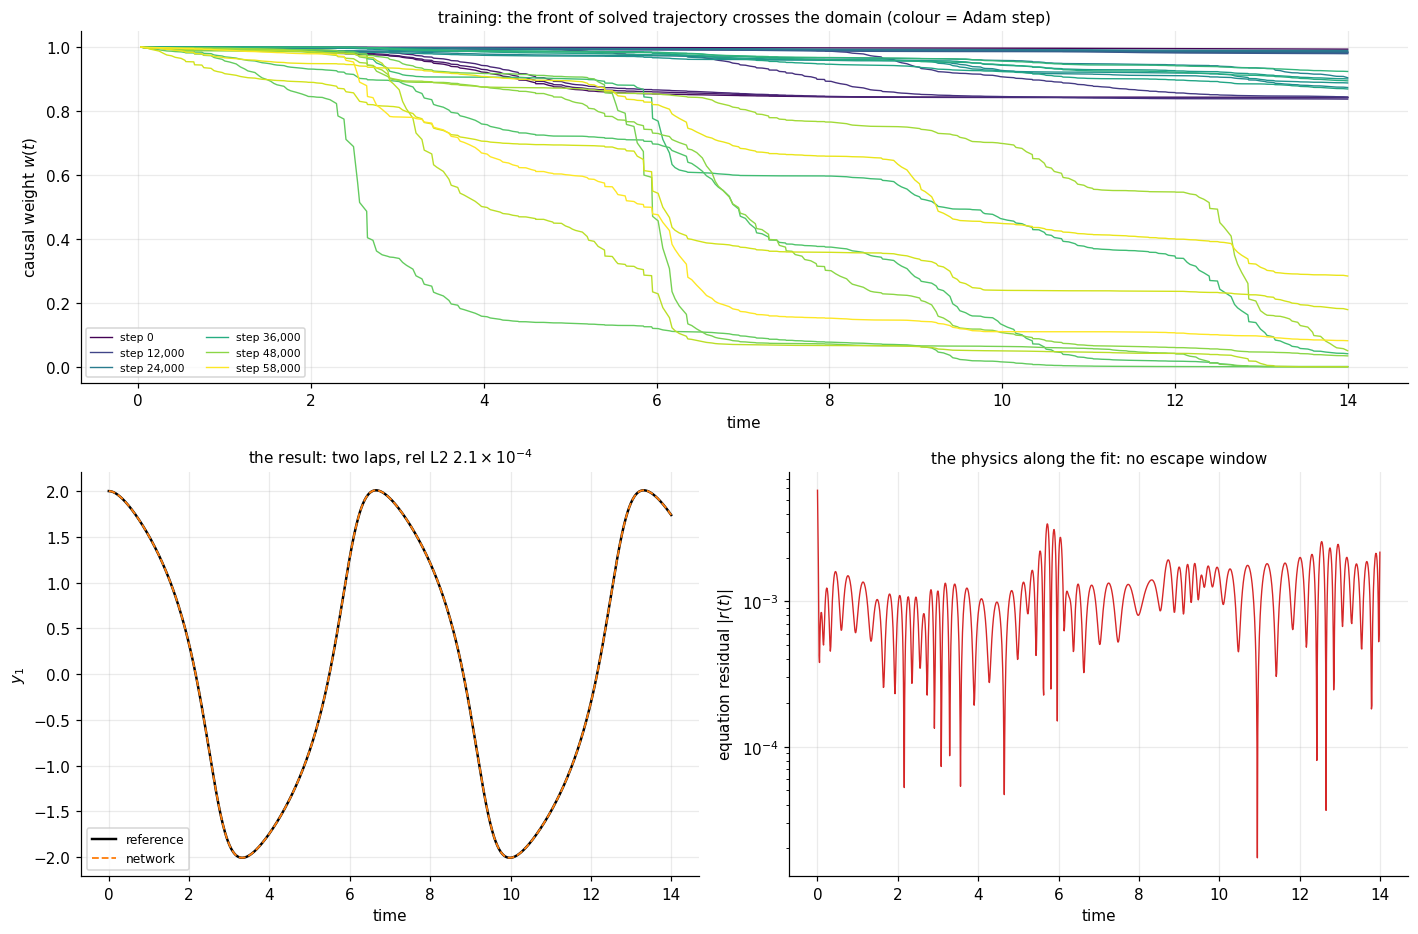

In [6]:
cw = Path.cwd().parent / "Causal_weighting" / "results"
pred = dict(np.load(cw / "predictions.npz"))
prof = dict(np.load(cw / "weight_profiles.npz"))
key = "T14_seed0"
t = pred["t_T14"]; y_net = pred[f"{key}_y_net"]
t_ref, y_ref = cap.reference(np.array([2.0, 0.0]), 14.0)

fig = plt.figure(figsize=(13, 8.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

ax = fig.add_subplot(gs[0, :])
W = prof[f"{key}_weights"]; steps = prof[f"{key}_steps"]; tc = prof[f"{key}_times"]
cmap = plt.get_cmap("viridis")
for k in range(len(W)):
    ax.plot(tc, W[k], color=cmap(k / max(len(W)-1, 1)), lw=0.9,
            label=(f"step {steps[k]:,}" if k % max(len(W)//5, 1) == 0
                   or k == len(W)-1 else None))
ax.set_xlabel("time"); ax.set_ylabel("causal weight $w(t)$")
ax.set_title("training: the front of solved trajectory crosses the domain (colour = Adam step)",
             fontsize=10)
ax.legend(fontsize=7, ncol=2, loc="lower left")

ax = fig.add_subplot(gs[1, 0])
ax.plot(t_ref, y_ref[:, 0], "k-", lw=1.6, label="reference")
ax.plot(t, y_net[:, 0], "--", color="C1", lw=1.2, label="network")
ax.set_xlabel("time"); ax.set_ylabel("$y_1$")
ax.set_title("the result: two laps, rel L2 $2.1\\times10^{-4}$", fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 1])
ax.semilogy(t, pred[f"{key}_residual"], color="C3", lw=0.9)
ax.set_xlabel("time"); ax.set_ylabel("equation residual $|r(t)|$")
ax.set_title("the physics along the fit: no escape window", fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES / "E_worked_example.png", bbox_inches="tight")
plt.show()